# Pruebas de la decodificación de señales y espectros

En este notebook se realizan pruebas para obtener los datos de la señal y espectro a partir de su codificación en Base64.

## Imports y paths

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parents[0]  # ajusta el número si hace falta
sys.path.append(str(repo_root))

In [ ]:
import json
import zlib

import matplotlib.pyplot as plt
import numpy as np

from src.t8_client.models.spectra import SpectraData
from src.t8_client.models.waveform import WaveformData

WAVE_PATH = "data/waves/wave_LP_Turbine_MAD32CY005_AM2_0.json"
SPECTRA_PATH = "data/spectra/spectrum_LP_Turbine_MAD32CY005_AM2_0.json"

## Decodificación

In [3]:
wave_json = json.loads((repo_root / WAVE_PATH).read_text())
spectra_json = json.loads((repo_root / SPECTRA_PATH).read_text())
wave = WaveformData.parse_obj(wave_json)
spectrum = SpectraData.parse_obj(spectra_json)

### Waveform

In [13]:
# se usa una versión en la que no se convierte a ndarray
raw = wave.decode(dtype=np.float64)
print(raw[:32]) #<-- zlib
# Descomprimir con zlib
decompressed = zlib.decompress(raw)
decompressed[:200] #<-- parece int16 con little-endian

waveform = np.frombuffer(decompressed, dtype="<i2")  # little-endian int16
waveform[:20]# <-- OK


b'x\x9c,\x97\tpUU\x9e\xc6\x01Q\xd9D\xa0\x81\x06\x12\tK01$$yYX\x12\x12H\x80\x90'


array([-32658, -32661, -32661, -32676, -32673, -32678, -32691, -32678,
       -32701, -32708, -32734, -32738, -32735, -32724, -32700, -32697,
       -32669, -32676, -32683, -32696], dtype=int16)

### Spectrum

In [14]:
# se usa una versión en la que no se convierte a ndarray
raw = spectrum.decode(dtype=np.float64)
print(raw[:32]) #<-- zlib
# Descomprimir con zlib
decompressed = zlib.decompress(raw)
decompressed[:200] #<-- parece int16 con little-endian

spectra = np.frombuffer(decompressed, dtype="<i2")  # little-endian int16
spectra[:20]# <-- OK

b'x\x9c4\xd6ip]\xe5y\x07\xf0\xdf{\xee\xd5bmW\xfb\xae\xab\xcd\xd7\xba\x96,YR$k\xb1%'


array([  508,   682,   656,  1562,   758,   439,   501,   441, 15871,
       32767, 16898,   167,   146,  1002,   985,   644,   318,   312,
         622,   603], dtype=int16)

## Visualización

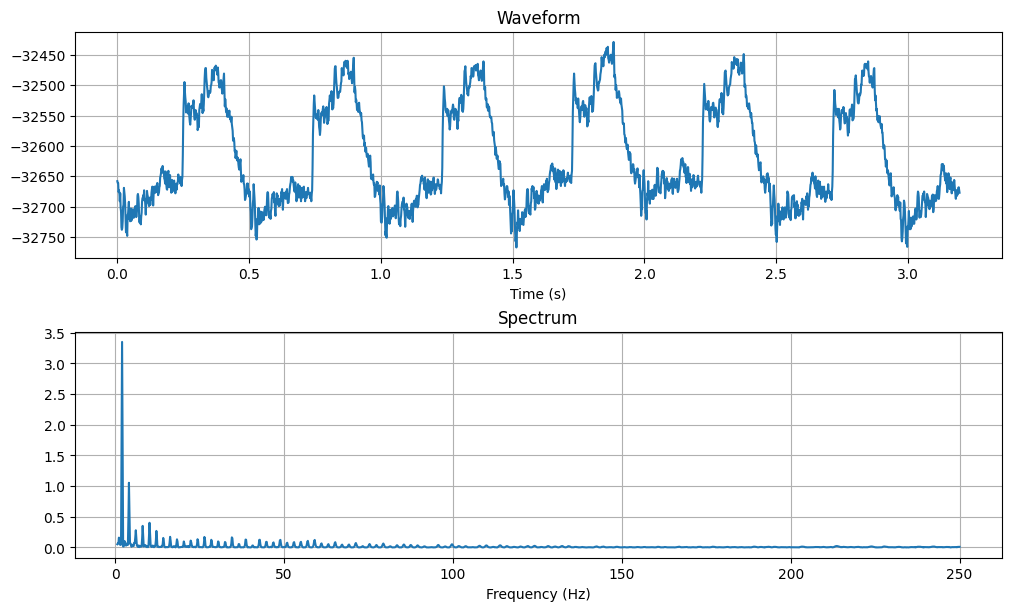

In [ ]:
# Waveform plot (use sample_rate if available)
sr = getattr(wave, "sample_rate", None)
fig, axs = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

if sr is not None:
    t = np.arange(waveform.size) / sr
    axs[0].plot(t, waveform)
    axs[0].set_xlabel("Time (s)")
else:
    axs[0].plot(waveform)
    axs[0].set_xlabel("Sample")
axs[0].set_title("Waveform")
axs[0].grid(True)

# Spectrum plot (use min_freq/max_freq and factor if available)
minf = getattr(spectrum, "min_freq", None)
maxf = getattr(spectrum, "max_freq", None)
if (minf is not None) and (maxf is not None):
    freqs = np.linspace(minf, maxf, spectra.size)
else:
    freqs = np.arange(spectra.size)

y = spectra.astype(float)
factor = getattr(spectrum, "factor", None)
if factor is not None:
    y *= factor

axs[1].plot(freqs, y)
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_title("Spectrum")
axs[1].grid(True)

plt.show()

Todo OK, problema resuelto